In [1]:
 class MyLinearRegression:
    def __init__(self, weight=10, bias=20, learning_rate=0.3,
                 iterations=180):
        self.weight = weight
        self.bias = bias
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_trend = []
        self.cost = 0

    def predict(self, x):
        predicted_set = []
        for i in range(len(x)):
            predicted_value = self.weight * x[i] + self.bias
            predicted_set.append(predicted_value)
        return predicted_set

    def cost_function(self, x, y):
        count = len(x)
        total_error = 0.0
        for i in range(count):
            total_error += (y[i] - (self.weight * x[i] +
                            self.bias)) ** 2
        return float(total_error) / (2 * count)

    def update_weights(self, x, y):
        weight_deriv = 0
        bias_deriv = 0
        count = len(x)

        for i in range(count):
            # Calculate partial derivatives
            # -2x(y - (mx + b))
            weight_deriv += -2 * x[i] * (y[i] -(self.weight * x[i] + self.bias))

            # -2(y - (mx + b))
            bias_deriv += -2 * (y[i] - (self.weight * x[i] +
                                self.bias))

        # We subtract because the derivatives point in direction of steepest
        # ascent
        self.weight -= (weight_deriv / count) * self.learning_rate
        self.bias -= (bias_deriv / count) * self.learning_rate

    def train(self, x, y):
        for i in range(self.iterations):
            self.update_weights(x, y)
            # Calculating cost
            self.cost = self.cost_function(x, y)
            self.cost_trend.append(self.cost)
           # if i % 10000 == 0:
            print("Iteration: {}\t Weight: {}\t Bias: {}\t Cost: {}".format(i, self.weight, self.bias, self.cost))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# intialise data of lists.
data = {'Hours':[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8],
        'Scores':[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]}

# Create DataFrame
studentscores = pd.DataFrame(data)

# Print the output.
studentscores

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


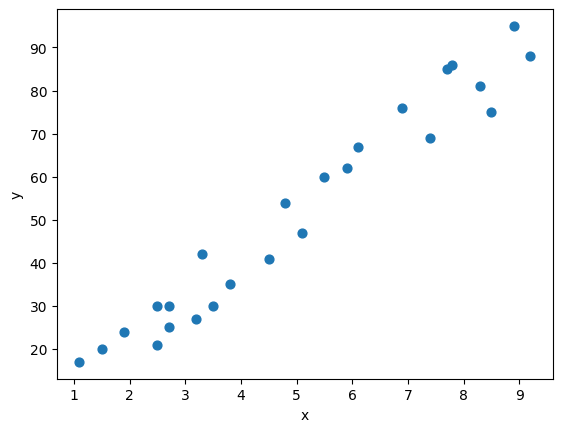

In [3]:
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y,s=40)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [4]:
#from my_linear_regression import MyLinearRegression
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing the dataset

X = studentscores.iloc[:, :-1].values
y = studentscores.iloc[:, -1].values
X,y

(array([[2.5],
        [5.1],
        [3.2],
        [8.5],
        [3.5],
        [1.5],
        [9.2],
        [5.5],
        [8.3],
        [2.7],
        [7.7],
        [5.9],
        [4.5],
        [3.3],
        [1.1],
        [8.9],
        [2.5],
        [1.9],
        [6.1],
        [7.4],
        [2.7],
        [4.8],
        [3.8],
        [6.9],
        [7.8]]),
 array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
        24, 67, 69, 30, 54, 35, 76, 86]))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

# Fitting Simple Linear Regression to the Training set
regressor = MyLinearRegression()
regressor.train(X_train, y_train) #supervised training
print('Weight: ' + str(regressor.weight) + ' Bias: ' + str(regressor.bias))

# Predicting the Test set results
y_pred = regressor.predict(X_test)


/tmp/ipykernel_198/2922692307.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(total_error) / (2 * count)
/tmp/ipykernel_198/2922692307.py:22: RuntimeWarning: overflow encountered in square
  total_error += (y[i] - (self.weight * x[i] +


Iteration: 0	 Weight: [-51.7025]	 Bias: [8.525]	 Cost: 62421.18748543359
Iteration: 1	 Weight: [1186.78110812]	 Bias: [199.2234125]	 Cost: 24891142.77544229
Iteration: 2	 Weight: [-23546.46512544]	 Bias: [-3644.29784222]	 Cost: 9931464628.788105
Iteration: 3	 Weight: [470502.29932582]	 Bias: [73099.01798513]	 Cost: 3962619107930.959
Iteration: 4	 Weight: [-9398065.88526271]	 Bias: [-1459867.99517217]	 Cost: 1581070952490070.2
Iteration: 5	 Weight: [1.87725556e+08]	 Bias: [29160963.50378761]	 Cost: 6.308416955394944e+17
Iteration: 6	 Weight: [-3.74979818e+09]	 Bias: [-5.82486967e+08]	 Cost: 2.517035963530861e+20
Iteration: 7	 Weight: [7.49018268e+10]	 Bias: [1.16351165e+10]	 Cost: 1.004288411261346e+23
Iteration: 8	 Weight: [-1.49615616e+12]	 Bias: [-2.32410235e+11]	 Cost: 4.007075097882177e+25
Iteration: 9	 Weight: [2.98855629e+13]	 Bias: [4.64237015e+12]	 Cost: 1.5988087346244457e+28
Iteration: 10	 Weight: [-5.96960995e+14]	 Bias: [-9.27308585e+13]	 Cost: 6.37919007622897e+30
Iteratio

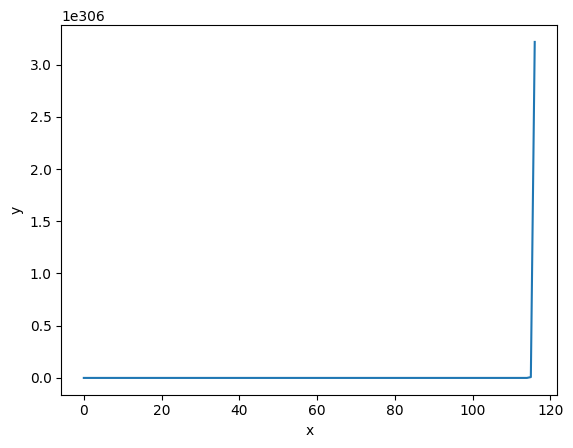

In [8]:
x=[int(x) for x in range(180)]
y=regressor.cost_trend
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

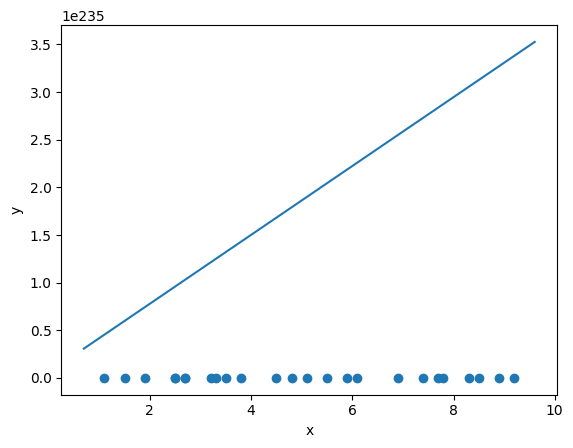

In [10]:
w = regressor.weight
b = regressor.bias
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = b + w * x_vals
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [11]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)

# Simple comparison
print("COMPARISON OF PREDICTED VS ACTUAL VALUES:")
print("-" * 40)
for i in range(len(y_pred)):
    # Convert to float to avoid formatting issues
    pred_val = float(y_pred[i])
    actual_val = float(y_test[i])
    diff = abs(pred_val - actual_val)
    print(f"Predicted: {pred_val:.2f} | Actual: {actual_val:.2f} | Difference: {diff:.2f}")

# Calculate accuracy
errors = []
for i in range(len(y_pred)):
    error = abs(float(y_pred[i]) - float(y_test[i]))
    errors.append(error)

average_error = sum(errors) / len(errors)
print("-" * 40)
print(f"Average Error: {average_error:.2f}")
print(f"Best Prediction: {min(errors):.2f} off")
print(f"Worst Prediction: {max(errors):.2f} off")


COMPARISON OF PREDICTED VS ACTUAL VALUES:
----------------------------------------
Predicted: 5980200890990180826675793832941994854975389872062187453465263963253190437276677699466208711114857075473325226678352818382156208109329725614750955911601594354683641277692257136172037865248360392842704349005880970958142124201843894517760.00 | Actual: 20.00 | Difference: 5980200890990180826675793832941994854975389872062187453465263963253190437276677699466208711114857075473325226678352818382156208109329725614750955911601594354683641277692257136172037865248360392842704349005880970958142124201843894517760.00
Predicted: 12121750327963431219091054863237363584726736583109917338951532485253833231020914860827817890790456859166848392960244611515559391555498653497188801083602838703984367343697814715634747381160247814267745534639297361186612209135208215085056.00 | Actual: 27.00 | Difference: 121217503279634312190910548632373635847267365831099173389515324852538332310209148608278178907904568591668483929602446

/tmp/ipykernel_198/4235529777.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_val = float(y_pred[i])
/tmp/ipykernel_198/4235529777.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error = abs(float(y_pred[i]) - float(y_test[i]))
